<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---



En esta notebook continuamos el trabajo iniciado en proyecto_eda.ipynb y proyecto_clean.inpynb.

El objetivo es construir modelos que puedan detectar automáticamente si un flujo de red es benigno o un ataque.

# 1. Preparación de los Datos

## 1.1 Librerías

In [71]:
# Librerías generales
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Librerías de scikit-learn para modelado
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')

# Colores consistentes con la Entrega 1
COLOR_BENIGNO = '#A1D99B'
COLOR_ATAQUE  = '#F8766D'
COLOR_NEUTRO  = '#AED6F1'

## 1.2 Carga del dataset
Con 2,8 millones de filas, entrenar modelos en Colab puede consumir demasiada memoria y tiempo. Por eso vamos a utilizar una muestra estratificada de 150.000 filas, que mantiene la proporción original de las clases y permite obtener resultados representativos con menor costo computacional.

La muestra df_muestra.parquet se carga directamente desde GitHub y ya se encuentra limpia, sin valores nulos ni columnas problemáticas, según el análisis realizado en proyecto_eda.ipynb.

In [2]:
# Configuración
GITHUB_USER   = 'jotaeleb'
GITHUB_REPO   = 'tif-ciencias-de-datos'
GITHUB_BRANCH = 'main'
DATASET_DIR   = 'dataset'

BASE_URL = (
    f'https://raw.githubusercontent.com/'
    f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
)

FILE_NAME = 'df_muestra.parquet'

# Cargar dataset
url = f'{BASE_URL}/{FILE_NAME}'
df = pd.read_parquet(io.BytesIO(requests.get(url).content))

# Variables
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Resumen
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Variables numéricas: {len(num_cols)} | Variables categóricas: {len(cat_cols)}')
print(f'BENIGN: {(df["Label"] == "BENIGN").mean()*100:.2f}%')

Dataset: 149,990 filas × 64 columnas
Variables numéricas: 63 | Variables categóricas: 1
BENIGN: 80.32%


# 2. PRIMERA ITERACIÓN


## 2.1 Preparación: variables y codificación

Los modelos de scikit-learn trabajan con números, no con texto. Necesitamos:
1. Seleccionar las columnas numéricas que usaremos como predictores
2. Convertir la variable objetivo `Label` a números
3. Separar en conjunto de entrenamiento y de prueba

In [3]:
# Vista rápida de las primeras filas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,206,2,2,68,132,34,34,34.00,0.00,66,66,66.00,0.00,970873.79,19417.48,68.67,113.74,200,3,3,3.00,0.00,3,3,3,3.00,0.00,3,3,0,0,9708.74,9708.74,34,66,46.80,17.53,307.20,0,0,0,0,0,0,1,58.50,34.00,66.00,68,132,-1,-1,1,32,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
1,443,676974,9,6,1697,1221,1349,0,188.56,441.13,1069,2,203.50,425.30,4310.36,22.16,48355.29,47275.83,118426,4,676974,84621.75,64370.78,207316,4,459769,91953.80,97240.60,198671,1280,0,0,13.29,8.86,0,1349,182.38,408.04,166498.65,0,0,1,0,0,0,0,194.53,188.56,203.50,1697,1221,8192,65535,8,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
2,443,63161627,7,0,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.11,10500000.00,11900000.00,32100000,997609,63200000,10500000.00,11900000.00,32100000,997609,0,0.00,0.00,0,0,0,0,0.11,0.00,0,0,0.00,0.00,0.00,0,0,1,0,0,0,0,0.00,0.00,0.00,0,0,29200,-1,0,40,7009617.00,0.00,7009617,7009617,18700000.00,12300000.00,32100000,8023974,BENIGN


In [5]:
# Seleccionamos las variables
features = num_cols.copy()
X = df[features].copy()

# Convertimos los labels de texto a números (LabelEncoder)
le = LabelEncoder()
y = le.fit_transform(df['Label'])

print('Clases codificadas:')
for i, clase in enumerate(le.classes_):
    print(f'  {i} → {clase}')

print(f'\nForma de X: {X.shape}')
print(f'Forma de y: {y.shape}')

Clases codificadas:
  0 → BENIGN
  1 → Bot
  2 → DDoS
  3 → DoS GoldenEye
  4 → DoS Hulk
  5 → DoS Slowhttptest
  6 → DoS slowloris
  7 → FTP-Patator
  8 → Infiltration
  9 → PortScan
  10 → SSH-Patator
  11 → Web Attack - Brute Force
  12 → Web Attack - Sql Injection
  13 → Web Attack - XSS

Forma de X: (149990, 63)
Forma de y: (149990,)


In [6]:
# Identificar clases con menos de 2 muestras
class_counts = Counter(y)
singleton_classes = [idx for idx, count in class_counts.items() if count < 2]

if singleton_classes:
    print("Clases con 1 sola muestra encontradas.")

    # Crear máscaras para separar los datos
    # Asumiendo que 'y' puede ser convertido a un array de numpy o es una Serie de Pandas
    y_array = np.array(y)
    is_singleton = np.isin(y_array, singleton_classes)

    # Extraer las muestras únicas (usamos boolean indexing)
    # Nota: Ajusta esto si X es un numpy array en lugar de un DataFrame (usando X[is_singleton])
    if isinstance(X, pd.DataFrame):
        X_singletons = X[is_singleton]
    else:
        X_singletons = X[is_singleton] # Funciona igual para numpy arrays

    y_singletons = y_array[is_singleton]

    # Extraer el resto de los datos (los que sí se pueden estratificar)
    if isinstance(X, pd.DataFrame):
        X_rest = X[~is_singleton]
    else:
        X_rest = X[~is_singleton]

    y_rest = y_array[~is_singleton]

    print(f"Muestras únicas separadas: {len(y_singletons)}")
    print(f"Muestras restantes para estratificar: {len(y_rest)}")

    # Aplicar train_test_split SOLO al "resto" de los datos
    X_train_rest, X_test, y_train_rest, y_test = train_test_split(
        X_rest, y_rest, test_size=0.2, random_state=42, stratify=y_rest
    )

    # Añadir las muestras únicas de vuelta al conjunto de ENTRENAMIENTO
    if isinstance(X, pd.DataFrame):
        X_train = pd.concat([X_train_rest, X_singletons], ignore_index=True)
    else:
        X_train = np.vstack((X_train_rest, X_singletons))

    y_train = np.concatenate([y_train_rest, y_singletons])

else:
    # Si no hay clases problemáticas, usar el flujo normal
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("No se encontraron clases con menos de 2 muestras.")

print(f'\nDimensiones finales:')
print(f'Filas de entrenamiento: {X_train.shape[0]:,}')
print(f'Filas de prueba: {X_test.shape[0]:,}')

Clases con 1 sola muestra encontradas.
Muestras únicas separadas: 2
Muestras restantes para estratificar: 149988

Dimensiones finales:
Filas de entrenamiento: 119,992
Filas de prueba: 29,998


## 2.2 Entrenamiento del modelo base

El Árbol de Decisión es uno de los modelos más fáciles de entender e interpretar. Es ideal para comenzar porque no requiere normalizar los datos y sus resultados son explicables.

In [8]:
# Creamos el árbol de decisión con profundidad limitada (max_depth=5)
# Limitar la profundidad evita que el modelo sea demasiado complejo (sobreajuste)
arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol

DecisionTreeClassifier(max_depth=5, random_state=42)

In [9]:
# Entrenamos el modelo con los datos de entrenamiento
arbol.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [10]:
print('Modelo entrenado')
print(f'Profundidad real del árbol: {arbol.get_depth()}')
print(f'Número de nodos: {arbol.tree_.node_count}')

Modelo entrenado
Profundidad real del árbol: 5
Número de nodos: 47


## 2.3 Visualización del árbol

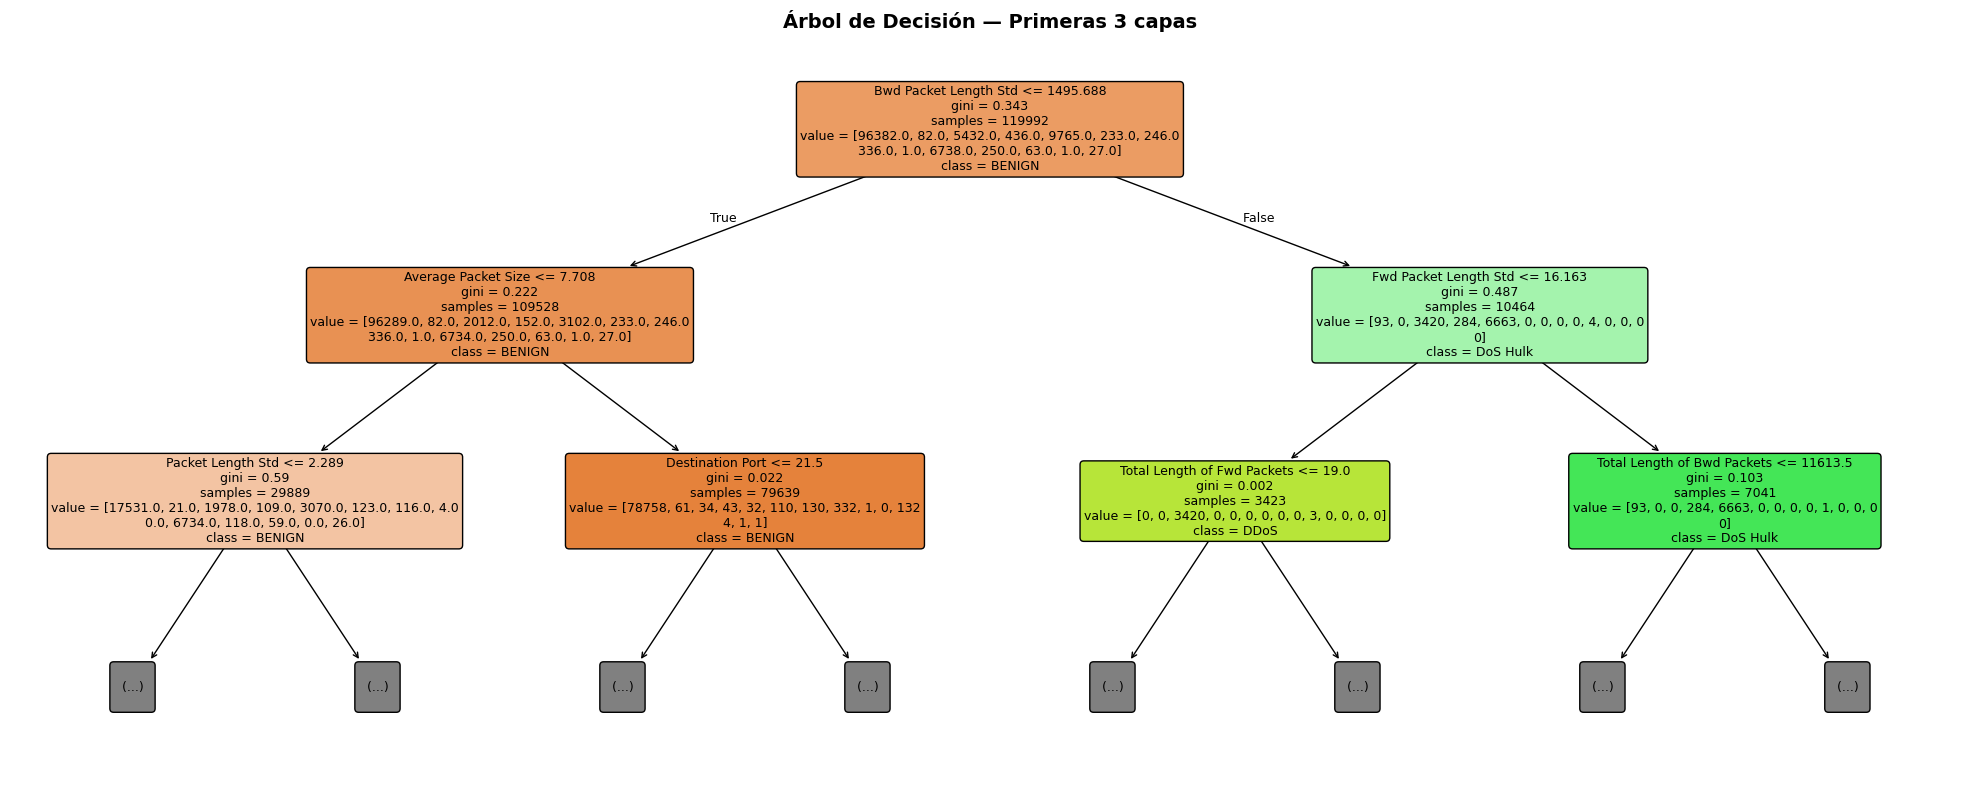

In [11]:
fig, ax = plt.subplots(figsize=(20, 8))

# Graficamos el árbol mostrando solo las primeras 2 capas para que sea legible
plot_tree(
    arbol,
    max_depth=2,
    feature_names=features,         # Nombres de las variables
    class_names=le.classes_,        # Nombres de las clases
    filled=True,                    # Colorear los nodos según la clase dominante
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Árbol de Decisión — Primeras 3 capas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cada nodo muestra la variable y el umbral que usa para dividir los datos. Los colores representan la clase dominante en ese grupo. Los nodos más "puros" (de un solo color) indican que el modelo está diferenciando bien las clases.

## 2.4 Evaluación del modelo

Usamos tres métricas principales:
- **Accuracy (exactitud)**: porcentaje de predicciones correctas en total
- **Precision**: de todos los que predije como ataque, ¿cuántos realmente lo eran?
- **Recall**: de todos los ataques reales, ¿cuántos detecté?

In [13]:
# Generamos predicciones sobre el conjunto de prueba
y_pred = arbol.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
# Accuracy: porcentaje de aciertos totales
accuracy = (y_pred == y_test).mean()
print(f'Accuracy del modelo: {accuracy:.2%}\n')

Accuracy del modelo: 96.58%



In [15]:
# Obtenemos todos los índices posibles de las clases originales
todas_las_clases = np.arange(len(le.classes_))

# Reporte de clasificación (opcionalmente ajustado a las clases presentes)
unique_labels_in_test = np.unique(np.concatenate([y_test, y_pred]))
filtered_target_names = le.inverse_transform(unique_labels_in_test)

print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, labels=unique_labels_in_test, target_names=filtered_target_names))

Reporte de clasificación:
                          precision    recall  f1-score   support

                  BENIGN       0.96      1.00      0.98     24096
                     Bot       0.00      0.00      0.00        21
                    DDoS       1.00      0.99      1.00      1358
           DoS GoldenEye       0.98      0.58      0.73       109
                DoS Hulk       0.96      0.72      0.82      2441
        DoS Slowhttptest       0.85      0.19      0.31        58
           DoS slowloris       1.00      0.34      0.51        61
             FTP-Patator       0.99      1.00      0.99        84
                PortScan       1.00      0.99      0.99      1685
             SSH-Patator       0.00      0.00      0.00        62
Web Attack - Brute Force       0.00      0.00      0.00        16
        Web Attack - XSS       0.00      0.00      0.00         7

                accuracy                           0.97     29998
               macro avg       0.65      0.48   

## 2.5 Matriz de Confusión

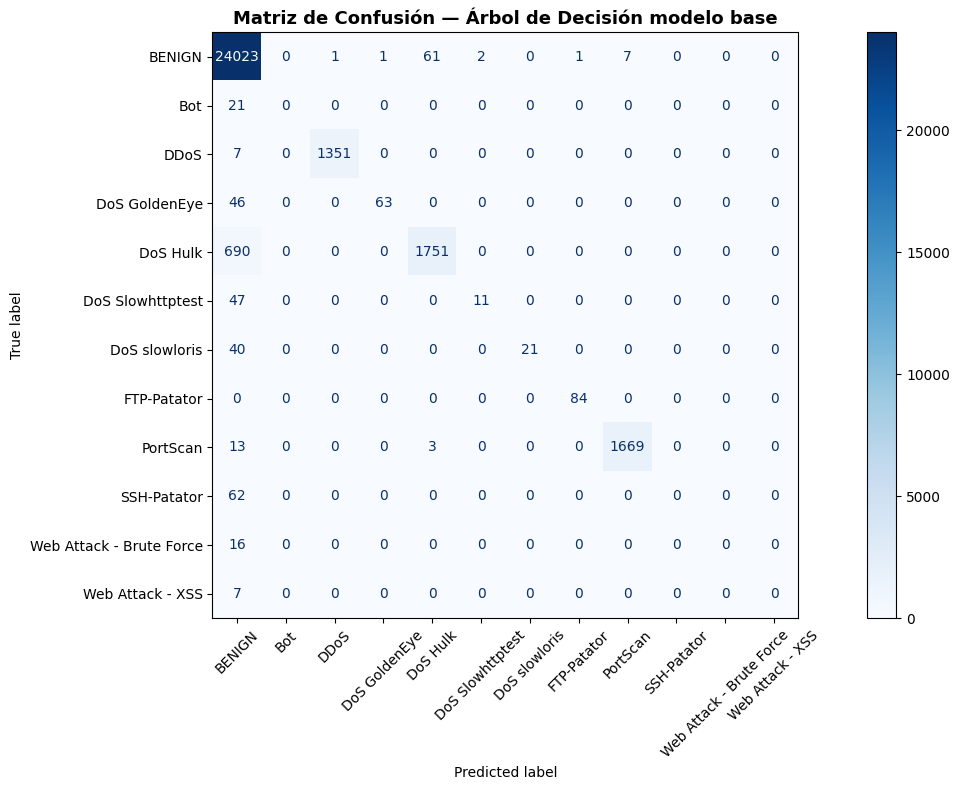

In [22]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 8))

# Usamos los nombres de las clases que realmente están presentes en el conjunto de prueba
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title('Matriz de Confusión — Árbol de Decisión modelo base', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La diagonal principal muestra los casos correctamente clasificados. Los valores fuera de la diagonal son errores. Si vemos que ciertos ataques se confunden con BENIGN, ese es el principal problema a mejorar.

## 2.6 Importancia de variables

El árbol de decisión puede decirnos qué tanto usó cada variable en sus decisiones. Esto nos ayuda a entender el problema e identificar variables importantes para el modelo.

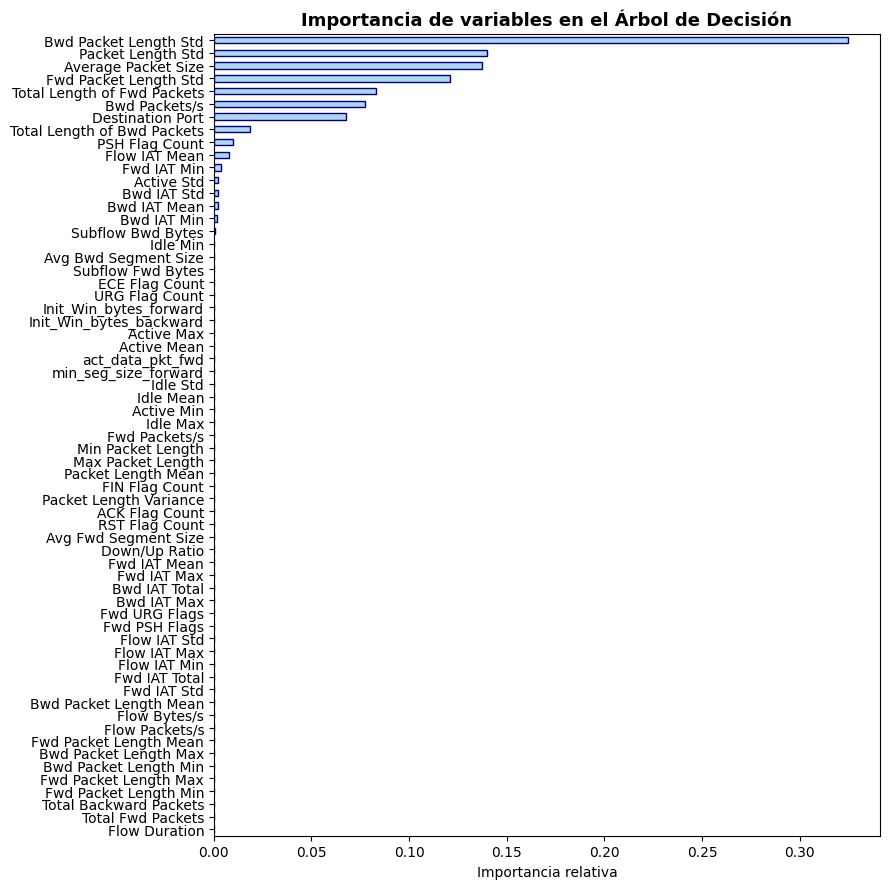


Top 3 variables más importantes:
Bwd Packet Length Std   0.32
Packet Length Std       0.14
Average Packet Size     0.14
dtype: float64


In [17]:
# Extraemos la importancia de cada variable
importancias = pd.Series(arbol.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
importancias.plot(kind='barh', ax=ax, color=COLOR_NEUTRO, edgecolor='navy')

ax.set_title('Importancia de variables en el Árbol de Decisión', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nTop 3 variables más importantes:')
print(importancias.sort_values(ascending=False).head(3))

# 3. SEGUNDA ITERACIÓN

## 3.1 Análisis Univariado de las variables predictoras

El análisis univariado describe cada variable por separado: cómo se distribuye, cuál es su rango, si tiene valores extremos, etc.

In [25]:
# Estadísticos descriptivos de las variables numéricas
# Usamos las variables que seleccionaremos como predictoras
desc = X.describe().T

# Agregamos coeficiente de variación
desc['CV (%)'] = (desc['std'] / desc['mean'].abs() * 100).round(1)

# Mostramos las 15 variables con mayor variabilidad
print('Variables con mayor variabilidad (Coeficiente de Variación):')
print(desc[['mean', 'std', 'min', 'max', 'CV (%)']].sort_values('CV (%)', ascending=False).head(15).to_string())

Variables con mayor variabilidad (Coeficiente de Variación):
                                  mean         std          min           max   CV (%)
min_seg_size_forward           -533.16   216598.23 -83885313.00        126.00 40625.50
Subflow Bwd Bytes              9746.95  1334739.34         0.00  512412358.00 13693.90
Total Length of Bwd Packets    9743.87  1333675.90         0.00  512000000.00 13687.30
act_data_pkt_fwd                  4.20      431.19         0.00     166021.00 10262.40
Fwd URG Flags                     0.00        0.01         0.00          1.00  9392.60
Total Backward Packets            7.63      604.96         0.00     232402.00  7924.70
Total Fwd Packets                 7.28      453.79         1.00     174013.00  6231.30
RST Flag Count                    0.00        0.02         0.00          1.00  6122.70
ECE Flag Count                    0.00        0.02         0.00          1.00  6122.70
Flow IAT Min                 167151.72  2992811.15       -13.00  1190

El coeficiente de variación (CV) mide qué tan dispersos están los valores de una variable respecto a su media. Un CV alto indica que la variable toma valores muy distintos entre registros, lo cual es útil para discriminar clases. Variables con CV bajo (poca variabilidad) suelen aportar menos al modelo.

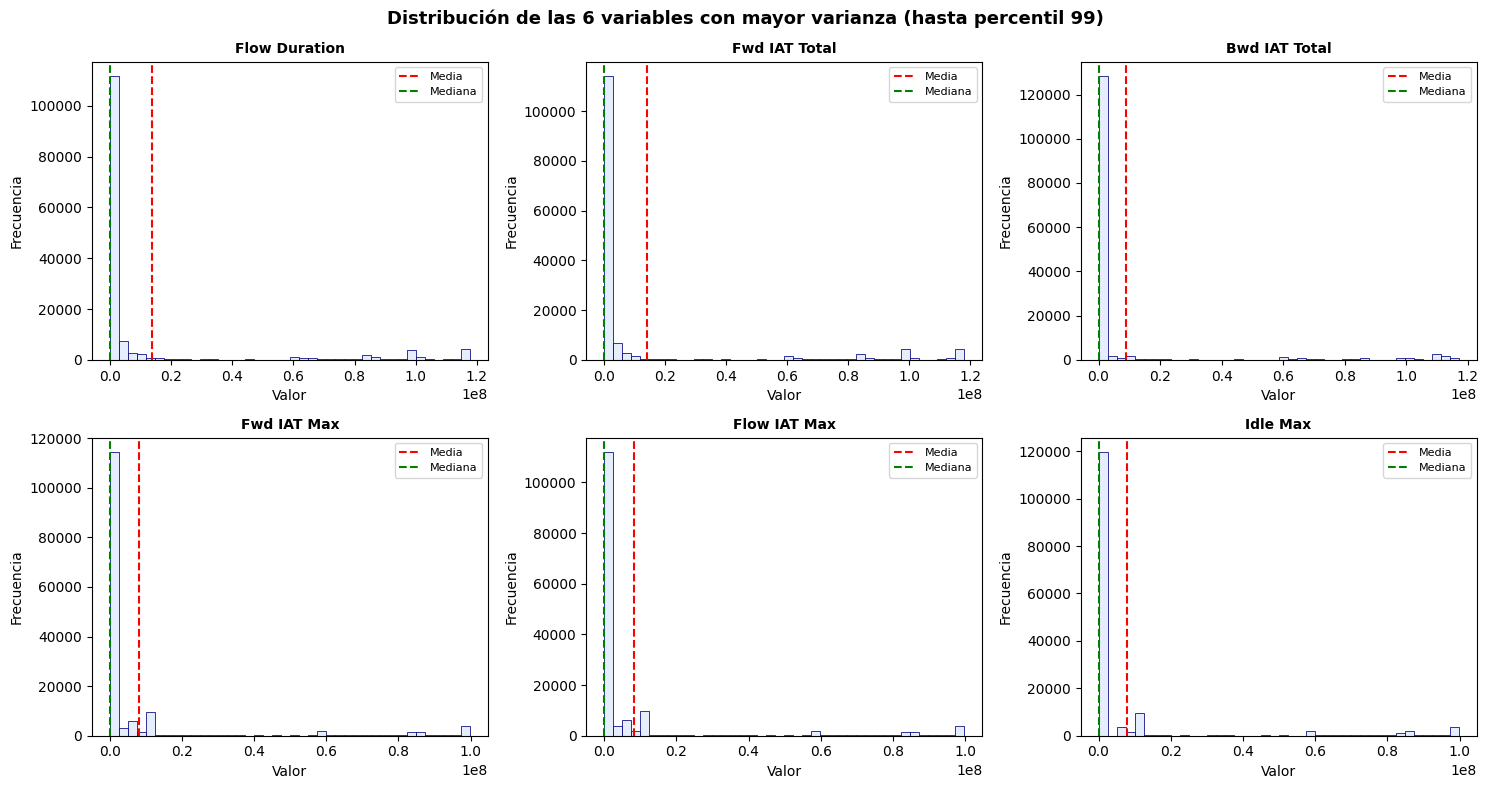

In [32]:
# Distribución de las 6 variables numéricas con mayor varianza
top6 = X.var().nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, top6):
    datos = X[col][X[col] <= X[col].quantile(0.99)]

    # Histograma optimizado
    sns.histplot(datos, bins=40, color='#E2EAFC', edgecolor='navy', alpha=0.85, ax=ax)

    # Líneas de tendencia en una sola línea cada una usando la etiqueta nativa
    ax.axvline(datos.mean(), color='red', ls='--', lw=1.5, label='Media')
    ax.axvline(datos.median(), color='green', ls='--', lw=1.5, label='Mediana')

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set(xlabel='Valor', ylabel='Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Distribución de las 6 variables con mayor varianza (hasta percentil 99)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La mayoría de las variables de tráfico de red tienen distribuciones muy asimétricas (sesgadas a la derecha): la mayoría de los flujos tienen valores bajos, pero algunos pocos generan valores enormes. Esto es típico en datos de red, donde el tráfico normal es moderado y los ataques como DDoS generan picos extremos. La diferencia entre la media (línea roja) y la mediana (línea verde) confirma esta asimetría.

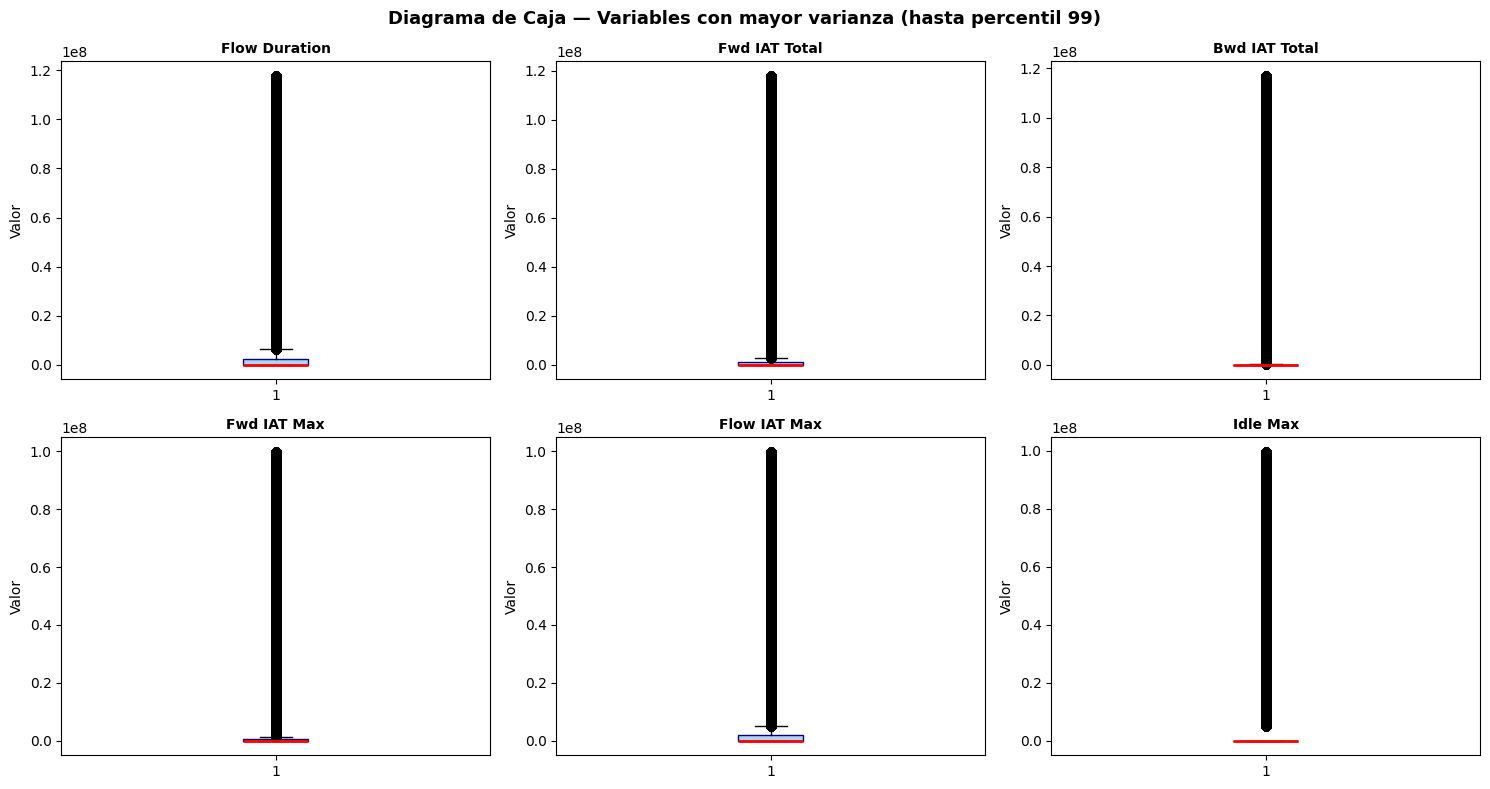

In [39]:
# Análisis de valores atípicos con diagrama de caja para las top 6 variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    limite = X[col].quantile(0.99)
    datos  = X[col][X[col] <= limite]

    axes[i].boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=COLOR_NEUTRO, color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor')

fig.suptitle('Diagrama de Caja — Variables con mayor varianza (hasta percentil 99)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El diagrama de caja muestra el rango intercuartílico (la caja, donde está el 50% central de los datos), la mediana (línea roja) y los bigotes (hasta 1.5 veces el rango intercuartílico). Los puntos fuera de los bigotes son valores atípicos. En datos de red es esperable que haya muchos outliers: un ataque DDoS genera valores de paquetes y bytes que están muy por encima del tráfico normal.

## 3.2 Análisis Bivariado — Variables predictoras vs. Variable objetivo

El análisis bivariado estudia cómo cambia cada variable según la clase. Si una variable tiene distribuciones muy distintas entre BENIGN y los tipos de ataque, será un buen predictor para el modelo.

In [34]:
# Creamos un dataframe combinado con las variables y la etiqueta de clase
df_plot = X[top6].copy()
df_plot['Label'] = df['Label'].values

# Calculamos la mediana de cada variable por clase para comparar
mediana_por_clase = df_plot.groupby('Label')[top6].median()

print('Mediana de las 6 principales variables por clase:')
print(mediana_por_clase.T.to_string())

Mediana de las 6 principales variables por clase:
Label           BENIGN      Bot       DDoS  DoS GoldenEye    DoS Hulk  DoS Slowhttptest  DoS slowloris  FTP-Patator  Infiltration  PortScan  SSH-Patator  Web Attack - Brute Force  Web Attack - Sql Injection  Web Attack - XSS
Flow Duration 31024.50 67867.00 1944986.50    11523546.00 85002016.00       63122273.00    99999078.00   8358618.50   56538478.00     47.00  10399957.00                5464853.00                  5006127.00        5399080.00
Fwd IAT Total     4.00 67867.00 1944986.50     6594227.00 84900000.00       63100000.00   100000000.00   5380313.50   56500000.00      0.00   8617458.00                5412219.00                     5712.00        5373657.00
Bwd IAT Total     3.00 66483.00   72772.00    10200000.00   125981.50              0.00    51100000.00   8358491.00          0.00      0.00  10400000.00                      0.00                  5005996.00              0.00
Fwd IAT Max       4.00 67039.00 1942814.00     647

Comparar las medianas por clase nos da una primera idea de qué tan distintas son las clases. Si para una variable la mediana de DDoS es 100 veces mayor que la de BENIGN, esa variable es muy útil para separar esas dos clases. Si las medianas son parecidas, la variable no ayuda mucho a distinguirlas.

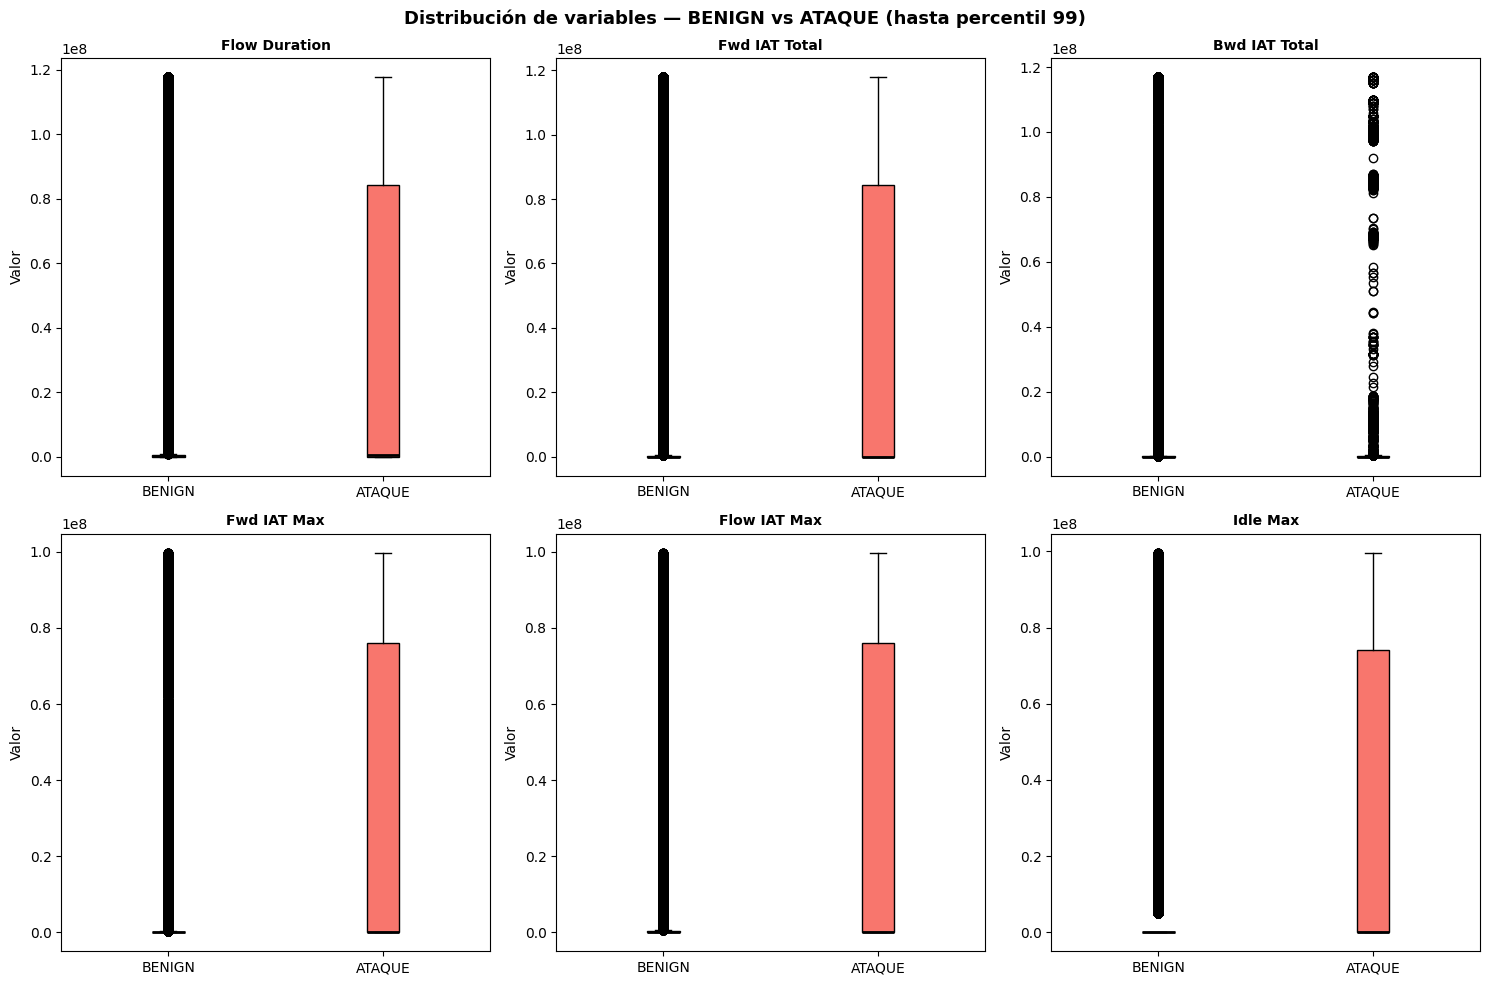

In [43]:
# Boxplot de las top 6 variables separadas por clase (benigno vs ataque)
# Creamos una variable binaria para simplificar la visualización
df_plot['Tipo'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATAQUE')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    limite = df_plot[col].quantile(0.99)
    datos_filtrados = df_plot[df_plot[col] <= limite]

    grupos = [datos_filtrados[datos_filtrados['Tipo'] == t][col].values
              for t in ['BENIGN', 'ATAQUE']]

    bp = axes[i].boxplot(grupos, labels=['BENIGN', 'ATAQUE'], patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_BENIGNO)
    bp['boxes'][1].set_facecolor(COLOR_ATAQUE)

    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor')

fig.suptitle('Distribución de variables — BENIGN vs ATAQUE (hasta percentil 99)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cuando las cajas de BENIGN y ATAQUE están en rangos muy distintos (poca superposición), la variable es un buen separador entre clases. Si las cajas se solapan mucho, el modelo va a tener más dificultad usando esa variable para distinguir el tipo de tráfico. Estas diferencias visuales anticipan qué variables serán más importantes según la importancia que calculará el árbol de decisión.

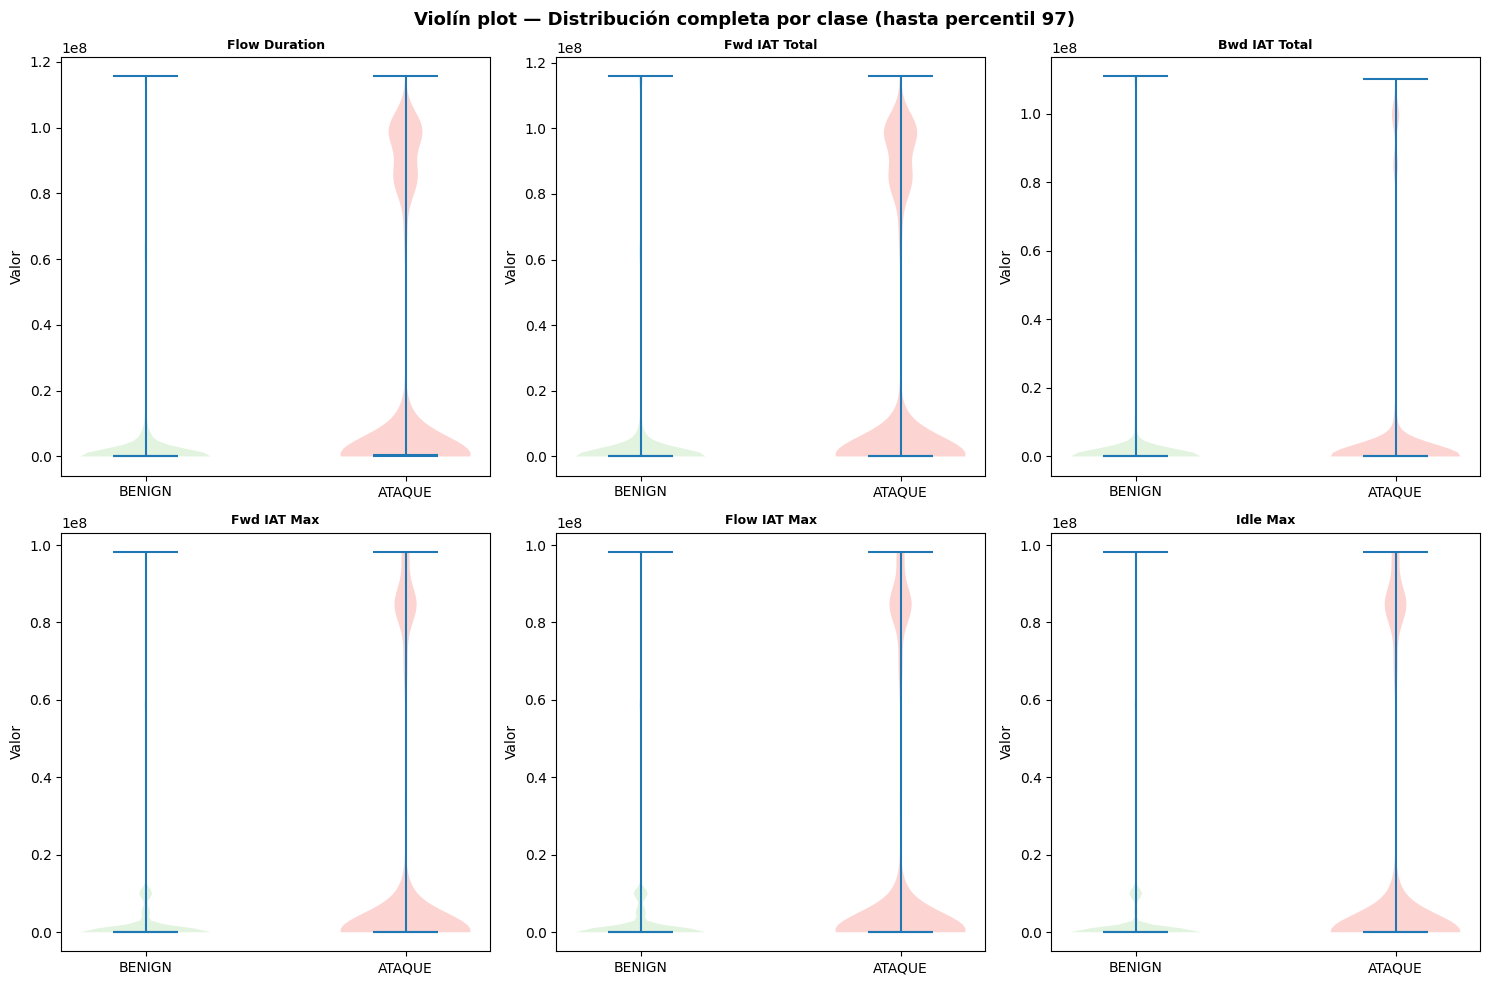

In [47]:
# Violín plot: muestra la distribución completa por clase para las 6 variables más importantes
top6 = X.var().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top4):
    limite = df_plot[col].quantile(0.97)
    datos_filtrados = df_plot[df_plot[col] <= limite]

    benign = datos_filtrados[datos_filtrados['Tipo'] == 'BENIGN'][col]
    ataque = datos_filtrados[datos_filtrados['Tipo'] == 'ATAQUE'][col]

    parts = axes[i].violinplot([benign, ataque], showmedians=True)
    parts['bodies'][0].set_facecolor(COLOR_BENIGNO)
    parts['bodies'][1].set_facecolor(COLOR_ATAQUE)

    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['BENIGN', 'ATAQUE'])
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valor')

fig.suptitle('Violín plot — Distribución completa por clase (hasta percentil 97)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El violín plot combina un boxplot con la distribución real de los datos (el "ancho" del violín muestra dónde se concentran más registros). Un violín angosto indica que los valores están concentrados en un rango estrecho; uno ancho indica mayor dispersión. Si el violín de ATAQUE es muy distinto al de BENIGN en forma y posición, esa variable discrimina bien las clases.

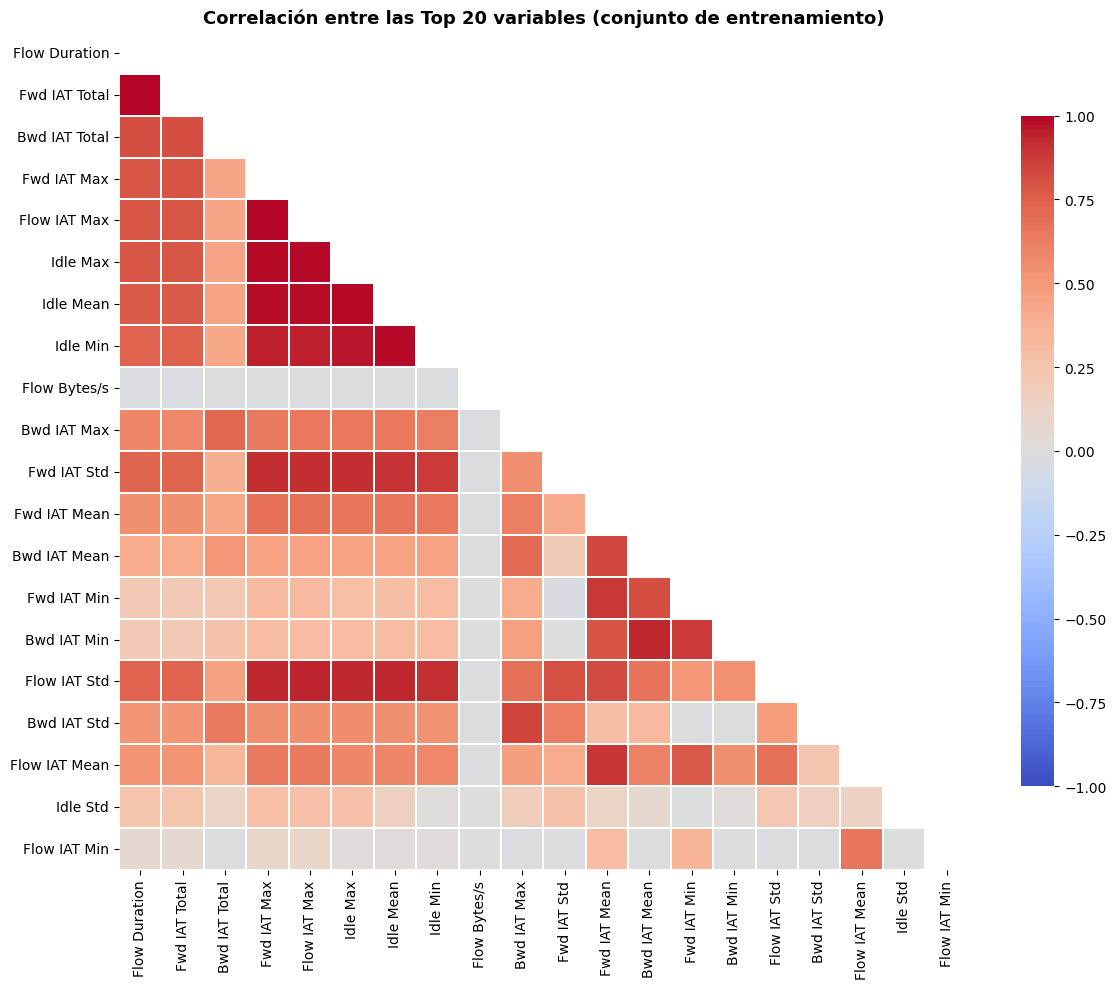

In [48]:
# Heatmap de correlación entre las top 20 variables (en datos de entrenamiento)
top20_var = X_train.var().sort_values(ascending=False).head(20).index.tolist()
corr = X_train[top20_var].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mascara = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr, mask=mascara, annot=False, cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlación entre las Top 20 variables (conjunto de entrenamiento)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** El mapa de calor muestra la correlación entre pares de variables:
- **Rojo oscuro (cerca de +1):** las dos variables suben y bajan juntas. Si una es alta, la otra también lo es. Estas variables suelen ser redundantes: aportan información similar al modelo.
- **Azul oscuro (cerca de -1):** cuando una sube, la otra baja. También es información útil pero opuesta.
- **Colores claros (cerca de 0):** las variables son independientes entre sí, cada una aporta información distinta.

La presencia de grupos de variables muy correlacionadas confirma que la selección de variables con ANOVA (que haremos en la siguiente sección) es una buena estrategia para eliminar redundancia.

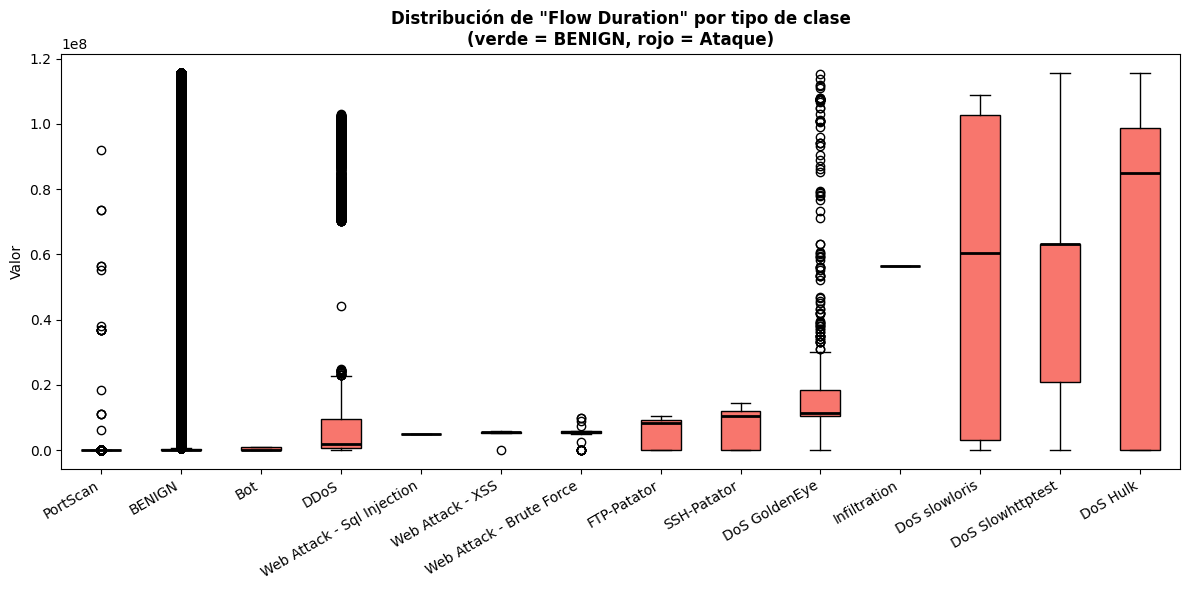

In [49]:
# Distribución de las variables predictoras por tipo de ataque (multiclase)
# Elegimos la variable con mayor poder discriminante para visualizar por clase
mejor_var = X.var().sort_values(ascending=False).index[0]
limite = df_plot[mejor_var].quantile(0.97)
datos_var = df_plot[df_plot[mejor_var] <= limite].copy()

# Calculamos mediana por clase para ordenar el gráfico
orden_clases = (datos_var.groupby('Label')[mejor_var].median()
                .sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
colores_clases = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden_clases]

datos_agrupados = [datos_var[datos_var['Label'] == c][mejor_var].values for c in orden_clases]

bp = ax.boxplot(datos_agrupados, labels=orden_clases, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), vert=True)

for box, color in zip(bp['boxes'], colores_clases):
    box.set_facecolor(color)

ax.set_xticklabels(orden_clases, rotation=30, ha='right')
ax.set_ylabel('Valor')
ax.set_title(f'Distribución de "{mejor_var}" por tipo de clase\n(verde = BENIGN, rojo = Ataque)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Este gráfico muestra cómo varía la variable más importante según cada tipo de clase. Es el análisis bivariado más directo: si cada clase tiene una caja en un rango distinto, el modelo podrá distinguirlas bien usando esa variable. Los tipos de ataque que tienen medianas similares a BENIGN serán los más difíciles de detectar correctamente (como Botnet o Infiltration, que generan tráfico parecido al normal).

In [50]:
# Resumen cuantitativo: diferencia entre clases para las top 10 variables
print('Diferencia relativa entre ATAQUE y BENIGN para las principales variables:')
print('(Cuántas veces mayor es la mediana de ATAQUE respecto a BENIGN)\n')

df_biv = X[X.var().sort_values(ascending=False).head(10).index].copy()
df_biv['Tipo'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATAQUE')

med_benign = df_biv[df_biv['Tipo'] == 'BENIGN'].drop('Tipo', axis=1).median()
med_ataque = df_biv[df_biv['Tipo'] == 'ATAQUE'].drop('Tipo', axis=1).median()

ratio = (med_ataque / med_benign.replace(0, 0.0001)).round(2)
ratio = ratio.sort_values(ascending=False)

for var, r in ratio.items():
    barra = '█' * min(int(r), 30)
    print(f'  {var[:35]:<35} {r:>8.1f}x  {barra}')

Diferencia relativa entre ATAQUE y BENIGN para las principales variables:
(Cuántas veces mayor es la mediana de ATAQUE respecto a BENIGN)

  Fwd IAT Total                         2492.4x  ██████████████████████████████
  Fwd IAT Max                           2251.5x  ██████████████████████████████
  Flow Duration                           14.6x  ██████████████
  Flow IAT Max                            13.8x  █████████████
  Flow Bytes/s                             0.0x  
  Bwd IAT Total                            0.0x  
  Idle Max                                 0.0x  
  Idle Mean                                0.0x  
  Idle Min                                 0.0x  
  Bwd IAT Max                              0.0x  


Este resumen muestra cuántas veces mayor es la mediana del tráfico de ataque respecto al benigno para cada variable. Un ratio de 50x significa que los ataques generan valores 50 veces más altos que el tráfico normal en esa variable, lo que la convierte en un predictor muy poderoso. Estas son exactamente las variables que el árbol de decisión y Random Forest usarán más en sus predicciones.

## 3.3 Selección de variables con ANOVA

**ANOVA F-test** compara la media de cada variable entre las distintas clases. Si una variable tiene medias muy distintas entre clases (por ejemplo, DDoS genera muchos más paquetes que BENIGN), su puntuación F será alta y la consideramos importante.

Vamos a seleccionar las **20 mejores** variables para trabajar con ellas.

In [53]:
# Aplicamos SelectKBest con ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train, y_train)

# Guardamos los nombres de las variables seleccionadas
mask = selector.get_support()
features_kbest = [f for f, m in zip(features, mask) if m]

print(f'Variables seleccionadas ({len(features_kbest)}):')
for v in features_kbest:
    print(f'  • {v}')

Variables seleccionadas (20):
  • Flow Duration
  • Bwd Packet Length Max
  • Bwd Packet Length Mean
  • Bwd Packet Length Std
  • Flow IAT Std
  • Flow IAT Max
  • Fwd IAT Total
  • Fwd IAT Std
  • Fwd IAT Max
  • Max Packet Length
  • Packet Length Mean
  • Packet Length Std
  • Packet Length Variance
  • FIN Flag Count
  • PSH Flag Count
  • Average Packet Size
  • Avg Bwd Segment Size
  • Idle Mean
  • Idle Max
  • Idle Min


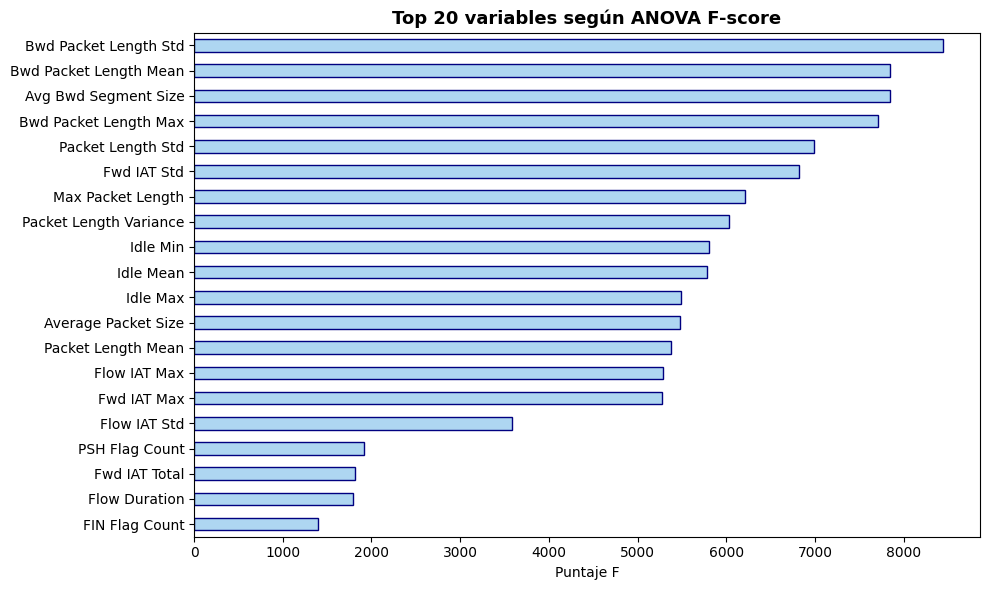

In [55]:
# Visualizamos los puntajes ANOVA de todas las variables
scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
scores.head(20).sort_values().plot(kind='barh', ax=ax, color=COLOR_NEUTRO, edgecolor='navy')
ax.set_title('Top 20 variables según ANOVA F-score', fontsize=13, fontweight='bold')
ax.set_xlabel('Puntaje F')
plt.tight_layout()
plt.show()

Las variables con puntaje F más alto son las que mejor separan las clases. Por ejemplo, variables relacionadas con el volumen de paquetes y bytes suelen ser claves para distinguir ataques DoS/DDoS del tráfico normal, ya que estos ataques generan un flujo masivo de datos.

In [56]:
# Creamos los conjuntos de datos con solo las variables seleccionadas
X_train_kb = X_train[features_kbest]
X_test_kb  = X_test[features_kbest]

print(f'Nuevas dimensiones de entrenamiento: {X_train_kb.shape}')
print(f'Nuevas dimensiones de prueba: {X_test_kb.shape}')

Nuevas dimensiones de entrenamiento: (119992, 20)
Nuevas dimensiones de prueba: (29998, 20)


## 3.4 Árbol de Decisión con variables seleccionadas

Repetimos el árbol de decisión pero ahora solo con las 20 variables que ANOVA identificó como más importantes.

In [61]:
# Entrenamos el árbol con las variables seleccionadas por ANOVA
arbol_kb = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol_kb

DecisionTreeClassifier(max_depth=5, random_state=42)

In [62]:
arbol_kb.fit(X_train_kb, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [63]:
y_pred_kb = arbol_kb.predict(X_test_kb)

In [66]:
# Accuracy
acc_kb = (y_pred_kb == y_test).mean()
print(f'Accuracy con KBest (20 variables): {acc_kb:.2%}')
print(f'Accuracy modelo base (63 variables): {(arbol.predict(X_test) == y_test).mean():.2%}')

Accuracy con KBest (20 variables): 95.88%
Accuracy modelo base (63 variables): 96.58%


In [67]:
# Reporte de clasificación
unique_kb = np.unique(np.concatenate([y_test, y_pred_kb]))
nombres_kb = le.inverse_transform(unique_kb)
print(classification_report(y_test, y_pred_kb, labels=unique_kb, target_names=nombres_kb))

                          precision    recall  f1-score   support

                  BENIGN       0.96      1.00      0.98     24096
                     Bot       0.00      0.00      0.00        21
                    DDoS       0.96      0.96      0.96      1358
           DoS GoldenEye       0.88      0.56      0.69       109
                DoS Hulk       0.95      0.70      0.80      2441
        DoS Slowhttptest       0.43      0.10      0.17        58
           DoS slowloris       1.00      0.10      0.18        61
             FTP-Patator       0.00      0.00      0.00        84
                PortScan       0.99      0.99      0.99      1685
             SSH-Patator       0.00      0.00      0.00        62
Web Attack - Brute Force       0.00      0.00      0.00        16
        Web Attack - XSS       0.00      0.00      0.00         7

                accuracy                           0.96     29998
               macro avg       0.51      0.37      0.40     29998
        

El accuracy con 20 variables es muy similar al de 63, confirma que muchas de las variables originales eran redundantes o poco informativas. Usar menos variables también hace el modelo más rápido y fácil de mantener.

# 4. OPTIMIZACIÓN DEL MODELO

## 4.1 Optimización con GridSearchCV

Hasta ahora usamos `max_depth=5` de forma arbitraria. **GridSearchCV** prueba automáticamente distintas combinaciones de parámetros y elige la que mejor funciona usando validación cruzada (divide los datos de entrenamiento en 3 partes y evalúa en cada una).

Parámetros que vamos a explorar:
- `max_depth`: profundidad máxima del árbol (3, 5, 10, None = sin límite)
- `min_samples_leaf`: mínimo de muestras en una hoja (1, 5, 10)
- `criterion`: función para medir la calidad de las divisiones (gini o entropy)

In [68]:
# Definimos los parámetros a probar
param_grid = {
    'max_depth'       : [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion'       : ['gini', 'entropy']
}

# GridSearchCV prueba todas las combinaciones con validación cruzada de 3 pliegues
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',   # priorizamos F1 porque las clases están desbalanceadas
    n_jobs=-1,               # usa todos los núcleos disponibles
    verbose=1
)

grid_search.fit(X_train_kb, y_train)

print('Mejores parámetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMejor F1-weighted en validación cruzada: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros encontrados:
  criterion: entropy
  max_depth: None
  min_samples_leaf: 1

Mejor F1-weighted en validación cruzada: 0.9833


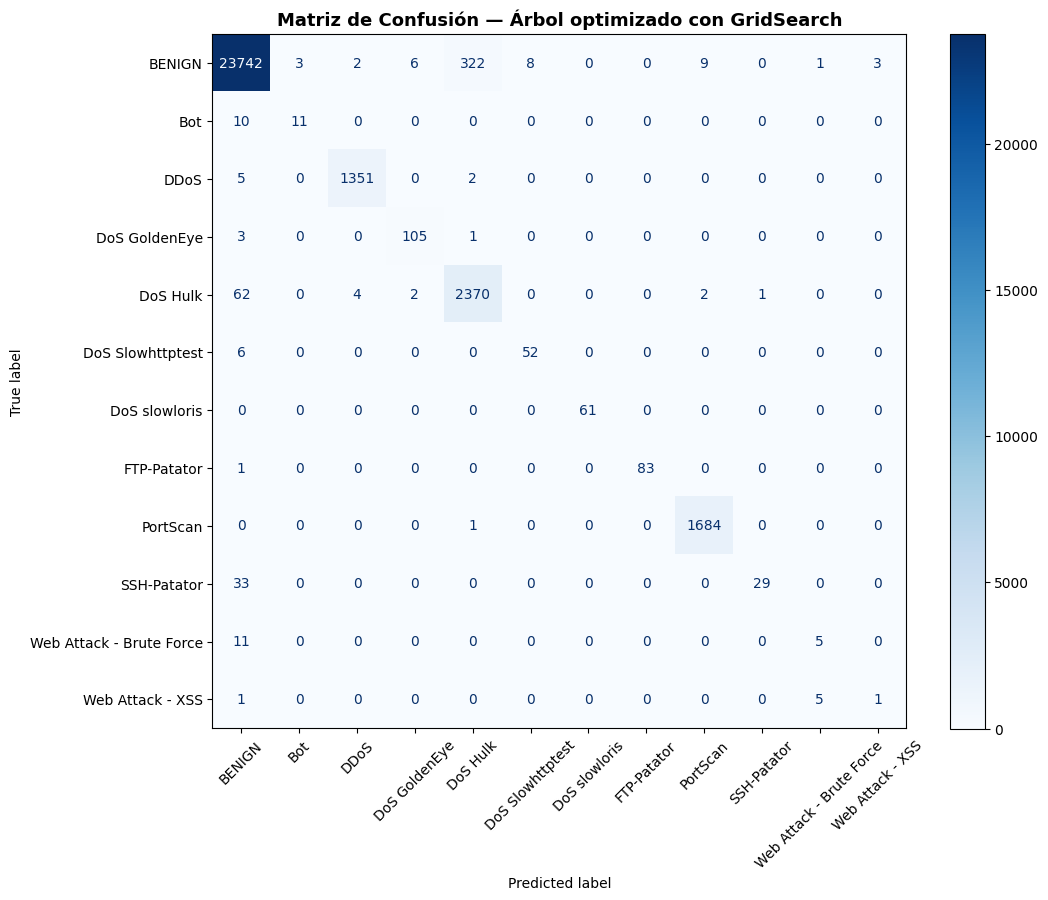

In [70]:
# Matriz de confusión del mejor árbol

# Obtener el mejor modelo y realizar predicciones
best_tree = grid_search.best_estimator_
y_pred_grid = best_tree.predict(X_test_kb)

# Obtener las etiquetas únicas y sus nombres para la matriz de confusión
unique_grid = np.unique(np.concatenate([y_test, y_pred_grid]))
nombres_grid = le.inverse_transform(unique_grid)

cm_grid = confusion_matrix(y_test, y_pred_grid, labels=unique_grid)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=nombres_grid)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Matriz de Confusión — Árbol optimizado con GridSearch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

GridSearch nos permitió ajustar los hiperparámetros de forma sistemática. El parámetro `min_samples_leaf` ayuda a evitar el sobreajuste (cuando el modelo memoriza los datos de entrenamiento pero falla con datos nuevos). Si el accuracy mejoró respecto al árbol base, el ajuste fue exitoso.

## 4.2 Optimización con RandomizedSearchCV

GridSearch prueba todas las combinaciones posibles. Si tenemos muchos parámetros, eso puede ser muy lento. **RandomizedSearchCV** prueba una muestra aleatoria de combinaciones (en este caso 20) y suele encontrar buenos resultados en mucho menos tiempo.

In [72]:
param_dist = {
    'max_depth' : [3, 5, 8, 10, 15, None],
    'min_samples_leaf' : [1, 2, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion' : ['gini', 'entropy'],
    'max_features' : ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist,
    n_iter=20, # probamos 20 combinaciones aleatorias
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_kb, y_train)

print('Mejores parámetros encontrados:')
for param, valor in random_search.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMejor F1-weighted: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros encontrados:
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: None
  max_depth: None
  criterion: entropy

Mejor F1-weighted: 0.9832


In [ ]:
# Evaluamos el resultado de RandomSearch
mejor_random = random_search.best_estimator_
y_pred_rand = mejor_random.predict(X_test_kb)

acc_rand = (y_pred_rand == y_test).mean()
print(f'Accuracy RandomSearch: {acc_rand:.2%}')
print()

unique_rand = np.unique(np.concatenate([y_test, y_pred_rand]))
nombres_rand = le.inverse_transform(unique_rand)
print(classification_report(y_test, y_pred_rand, labels=unique_rand, target_names=nombres_rand))

# 5. COMPARACIÓN DE MODELOS